# Consumer Credit Risk Modelling: 

## Loan Default Prediction with Canadian Macroeconomic Stress Testing for Credit Union Decision Support

## Project Modelling Architecture

This project adopts a **three-layer credit risk modelling framework** designed to capture borrower-level risk, macroeconomic conditions, and integrated portfolio risk behaviour.

- **Layer 1 — Micro-Level Credit Risk Modelling:** focuses on borrower-level LendingClub loan data to model individual default risk using credit, behavioural, and loan-specific features.
- **Layer 2 — Macroeconomic Risk Layer:** captures broader Canadian economic conditions using macroeconomic indicators such as interest rates, unemployment, inflation, household debt stress, and insolvency trends.
- **Layer 3 — Integrated Risk Modelling Layer:** combines insights from the borrower-level and macroeconomic layers to assess how individual credit risk interacts with changing economic conditions.

Together, these layers provide a structured framework for building a more comprehensive and realistic credit risk modelling solution, progressing from individual borrower behaviour to broader systemic risk analysis.

## Layer 1: LendingClub Loan Data Acquisition

The foundational micro-level dataset for this credit risk modelling project consists of historical LendingClub consumer loan records spanning **2007 to 2018**.

This dataset provides borrower-level loan application, credit profile, repayment behaviour, and loan performance information required for the development of the probability of default (PD) modelling framework.

As the primary modelling dataset, the LendingClub loan data forms the basis for target construction, feature engineering, exploratory analysis, and predictive model development within the micro-level credit risk layer.

The source dataset used in this project is the **accepted LendingClub loan dataset (`accepted_2007_to_2018Q4.csv`)**, obtained from the publicly available Kaggle repository:

https://www.kaggle.com/datasets/wordsforthewise/lending-club

This dataset serves as the core borrower-level data source for the credit risk modelling pipeline.

In [1]:
# Import core libraries for data manipulation, visualization,

import requests
import pandas as pd
import numpy as np
import zipfile
import io
import os
import matplotlib.pyplot as plt
import warnings
import missingno as msno
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')
os.makedirs('../data/raw/macro_chunks', exist_ok=True)

print('All imports OK')
print(f'Pandas version: {pd.__version__}')

All imports OK
Pandas version: 2.2.3


In [2]:
# Load Lendingclub loan dataset
# Load using low_memory=False to prevent mixed-type column warnings
df = pd.read_csv('../data/raw/accepted_2007_to_2018Q4.csv', low_memory=False)

print(f'The shape is {df.shape}')
print(f'The number of rows is {df.shape[0]} and the number of columns is {df.shape[1]} ')

The shape is (2260701, 151)
The number of rows is 2260701 and the number of columns is 151 


In [3]:
# View the entire columns from random samples of lendingclub dataset

# Show ALL columns without truncation
pd.set_option('display.max_columns', None, 'display.max_colwidth', None, 'display.width', None)

# View samples of the df
df.sample(5)

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,last_fico_range_high,last_fico_range_low,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
1441792,142665318,NaN,20000.0,20000.0,20000.0,36 months,12.73,671.29,B,B5,Letter Carrier,10+ years,RENT,64000.0,Verified,Oct-2018,Current,n,https://lendingclub.com/browse/loanDetail.action?loan_id=142665318,NaN,debt_consolidation,Debt consolidation,310xx,GA,20.59,2.0,Nov-2000,660.0,664.0,0.0,15.0,NaN,11.0,0.0,16354.0,74.0,16.0,w,17655.16,17655.16,3328.160000,3328.16,2344.84,983.32,0.0,0.0,0.0,Mar-2019,671.29,Apr-2019,Mar-2019,754.0,750.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,37745.0,1.0,2.0,1.0,1.0,6.0,21391.0,59.0,0.0,0.0,5148.0,74.0,21970.0,0.0,1.0,1.0,1.0,3431.0,4950.0,93.0,0.0,0.0,172.0,122.0,39.0,6.0,0.0,39.0,NaN,2.0,18.0,0.0,2.0,9.0,2.0,2.0,7.0,9.0,9.0,6.0,11.0,NaN,0.0,0.0,1.0,75.0,100.0,0.0,0.0,58200.0,37745.0,9900.0,36230.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
82571,63449018,NaN,26000.0,26000.0,26000.0,60 months,7.89,525.82,A,A5,Accountnat,5 years,RENT,150000.0,Source Verified,Oct-2015,Fully Paid,n,https://lendingclub.com/browse/loanDetail.action?loan_id=63449018,NaN,debt_consolidation,Debt consolidation,946xx,CA,4.78,0.0,Oct-1996,810.0,814.0,0.0,NaN,NaN,7.0,0.0,8014.0,12.3,19.0,w,0.00,0.00,28436.836292,28436.84,26000.00,2436.84,0.0,0.0,0.0,Jun-2017,7140.94,NaN,Mar-2019,789.0,785.0,0.0,NaN,1.0,Individual,NaN,NaN,NaN,0.0,0.0,11609.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51100.0,NaN,NaN,NaN,0.0,1658.0,36911.0,14.0,0.0,0.0,228.0,202.0,35.0,26.0,0.0,37.0,NaN,NaN,NaN,0.0,2.0,3.0,3.0,7.0,8.0,6.0,11.0,3.0,7.0,0.0,0.0,0.0,0.0,100.0,0.0,0.

In [4]:
# Loan Status distribution
print('A. Loan status value counts:')
print(df['loan_status'].value_counts())

print()
print(f'B. Total rows: {len(df):,}')

A. Loan status value counts:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64

B. Total rows: 2,260,701


### Observations from our Loan status distribution:

##### Fully Paid: 1,076,751
##### Charged Off: 268,559
##### Current: 878,317
##### Late / Grace Period: 21,467 + 8,436 + 4,349 = 34,252

The resolved loans (Fully Paid + Charged Off + Default) will be our working dataset since Current loans are still active — nobody knows yet if they'll be paid off or charged off so they can't be used to train a supervised model.

## Sorting Columns by Missingness and Visualizing Missing Data

When we sort our df columns based on the percentage of missing values in descending order, this helps us quickly identify the fields with the highest data gaps.

Next, the missing_data summary table was created showing:

The total number of missing values per column.
The percentage of missing values.
Sorted results (descending) to compare with the visual output.

Then visualize the missingness pattern using barchart plot, which provides a clear picture of the distribution of missing values across the dataset.

Both methods — column sorting the missing data table and visualizing it — confirm the same ranking of missingness.

In [5]:
# Null percentage by column/Percentage of Missing Data
# Columns with high null rates are unlikely to be useful features.

# Show ALL rows without truncation
pd.set_option('display.max_rows', None)

missing_data = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100)
})

missing_data.sort_values('Missing %', ascending=False)

,Missing Count,Missing %
member_id,2260701,100.000000
orig_projected_additional_accrued_interest,2252050,99.617331
hardship_reason,2249784,99.517097
hardship_payoff_balance_amount,2249784,99.517097
hardship_last_payment_amount,2249784,99.517097
payment_plan_start_date,2249784,99.517097
hardship_type,2249784,99.517097
hardship_status,2249784,99.517097
hardship_start_date,2249784,99.517097
deferral_term,2249784,99.517097


### Missing LendingClub Loan Data Overview

The table above summarizes the extent of missing data across all features in the LendingClub loan dataset, showing both the absolute number of missing values and the percentage of missing observations for each variable.

This assessment provides an initial data quality check, helping to identify features with substantial missingness that may require exclusion, imputation, or deeper investigation before model development.

In [6]:
# List of Columns with varying degrees of missingness in our dataset: 

high_missing_cols = missing_data.query("`Missing %` > 50").sort_values('Missing %', ascending=False)
moderate_missing_cols = missing_data.query("30 < `Missing %` <= 50").sort_values('Missing %', ascending=False)
low_missing_cols = missing_data.query("5 < `Missing %` <= 30").sort_values('Missing %', ascending=False)

print(f"Total columns with >50% missing data is: {high_missing_cols.shape[0]}")
print("Columns:", high_missing_cols.index.tolist())
print()
print(f"Total columns with >30%-50% missing data is: {moderate_missing_cols.shape[0]}")
print("Columns:", moderate_missing_cols.index.tolist())
print()
print(f"Total columns with over >5%-30% missing data is: {low_missing_cols.shape[0]}")
print("Columns:", low_missing_cols.index.tolist())
print()

Total columns with >50% missing data is: 44
Columns: ['member_id', 'orig_projected_additional_accrued_interest', 'hardship_dpd', 'hardship_length', 'deferral_term', 'hardship_last_payment_amount', 'hardship_end_date', 'hardship_start_date', 'hardship_reason', 'hardship_status', 'hardship_type', 'hardship_loan_status', 'hardship_amount', 'hardship_payoff_balance_amount', 'payment_plan_start_date', 'settlement_percentage', 'settlement_date', 'settlement_amount', 'settlement_status', 'debt_settlement_flag_date', 'settlement_term', 'sec_app_mths_since_last_major_derog', 'sec_app_revol_util', 'revol_bal_joint', 'sec_app_fico_range_low', 'sec_app_earliest_cr_line', 'sec_app_chargeoff_within_12_mths', 'sec_app_num_rev_accts', 'sec_app_inq_last_6mths', 'sec_app_mort_acc', 'sec_app_collections_12_mths_ex_med', 'sec_app_fico_range_high', 'sec_app_open_acc', 'sec_app_open_act_il', 'verification_status_joint', 'dti_joint', 'annual_inc_joint', 'desc', 'mths_since_last_record', 'mths_since_recent_bc

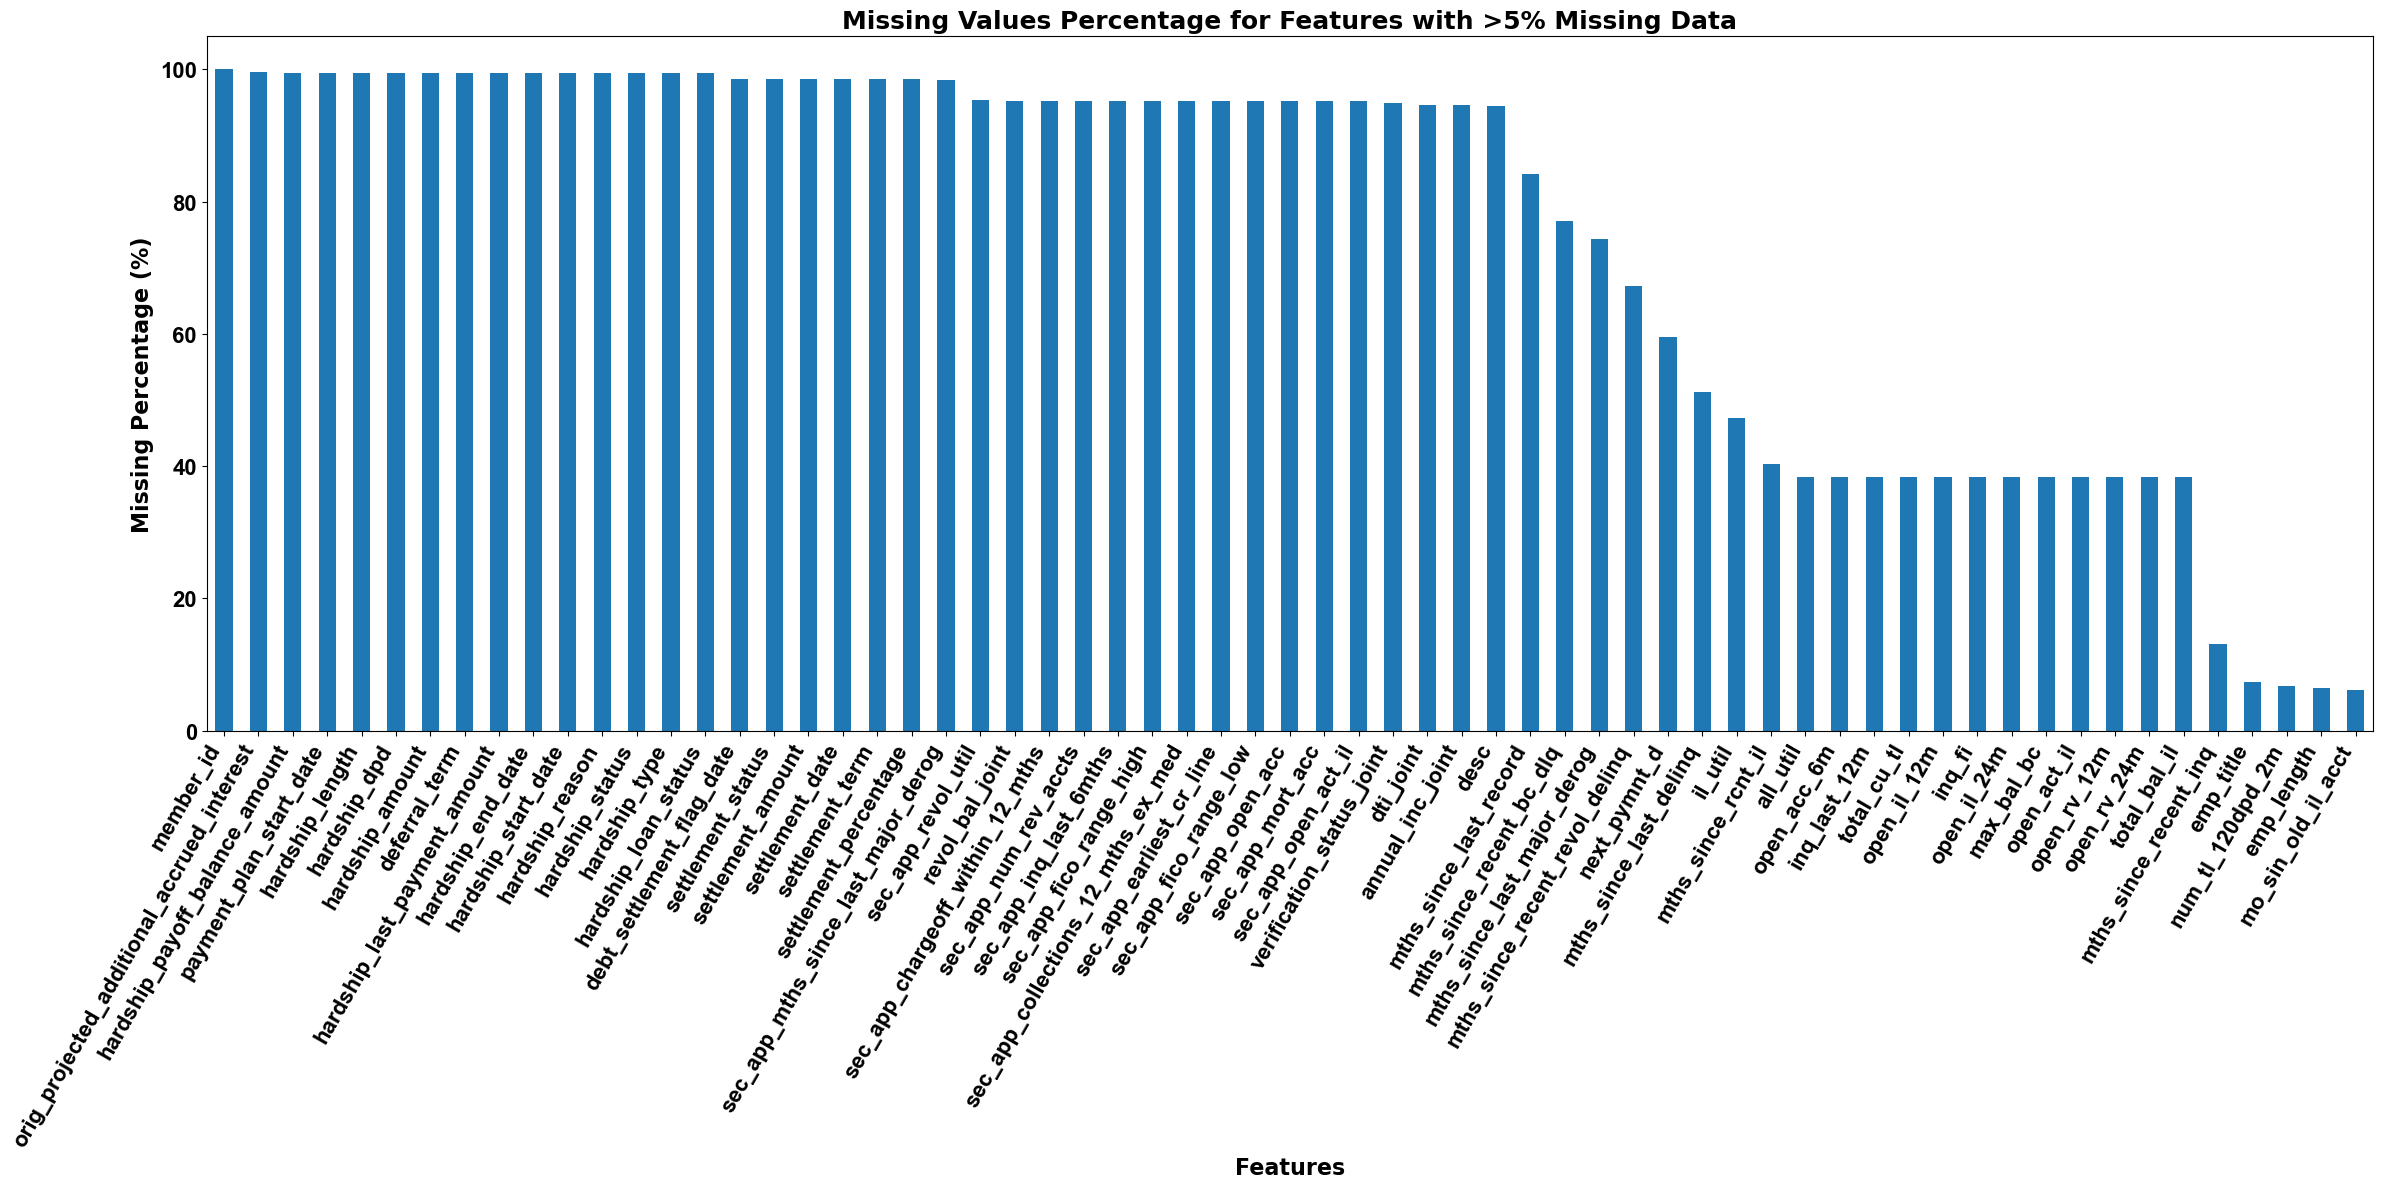

In [7]:
# Primary missingness analysis using bar chart

# Visualize columns with >5% missing data
missing_pct = missing_data[
    missing_data['Missing %'] > 5
]['Missing %'].sort_values(ascending=False)

plt.figure(figsize=(24, 12))
missing_pct.plot(kind='bar')

plt.xticks(rotation=60, fontsize=16, fontweight='bold', fontname='Arial', ha='right')
plt.yticks(fontsize=16, fontweight='bold', fontname='Arial')

plt.ylabel('Missing Percentage (%)', fontsize=16, fontweight='bold')
plt.xlabel('Features', fontsize=16, fontweight='bold')
plt.title('Missing Values Percentage for Features with >5% Missing Data', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
# Inspect dataset structure, feature completeness, and data types
df.info()
print()

# Display all feature names with their corresponding data types for schema review
print('LendingClub dataset columns and data types:')
print(df.dtypes.to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2260701 entries, 0 to 2260700
Columns: 151 entries, id to settlement_term
dtypes: float64(113), object(38)
memory usage: 2.5+ GB

LendingClub dataset columns and data types:
id                                             object
member_id                                     float64
loan_amnt                                     float64
funded_amnt                                   float64
funded_amnt_inv                               float64
term                                           object
int_rate                                      float64
installment                                   float64
grade                                          object
sub_grade                                      object
emp_title                                      object
emp_length                                     object
home_ownership                                 object
annual_inc                                    float64
verification_status 

In [9]:
# Confirming the date coverage period of the LendingClub accepted loans dataset

# issue_d is a string like 'Dec-2015' — preview only, do not parse yet
print('Issue date range (raw string):')
print(df['issue_d'].dropna().sort_values().iloc[[0, -1]].values)
print()
print('Unique issue_d formats (first 5):')
print(df['issue_d'].dropna().unique()[:5])

Issue date range (raw string):
['Apr-2008' 'Sep-2018']

Unique issue_d formats (first 5):
['Dec-2015' 'Nov-2015' 'Oct-2015' 'Sep-2015' 'Aug-2015']


## Loan Status Filtering for Reliable Target Construction

#### Loan Inclusion Criteria

Retain only loan records with clearly resolved repayment outcomes, and exclude loans with ongoing, ambiguous, or incomplete status classifications.

In [10]:
# We keep Statuses that the outcome are fully observed
INCLUDE_STATUSES = ['Fully Paid','Charged Off','Default']

# Exclude the following statuses
EXCLUDE_STATUSES = {
    'Current': 'Outcome unknown — loan still active',
    'Late (31-120 days)': 'Ambiguous — may recover or default',
    'In Grace Period ': 'Ambiguous — payment grace, unresolved',
    'Late (16-30 days)': 'Ambiguous — early delinquency unresolved',
    'Does not meet the credit policy. Status:Fully Paid':'Policy exception — selection bias' ,
    'Does not meet the credit policy. Status:Charged Off': 'Policy exception — selection bias' ,
    'Issued': 'No payment history — outcome unknown',
}

#
rows_before = len(df)
df_resolved = df[df['loan_status'].isin(INCLUDE_STATUSES)].copy()
rows_after = len(df_resolved)

print(f'Rows before inclusion filter: {rows_before:,}')
print(f'Rows after  inclusion filter: {rows_after:,}')
print(f'Rows removed: {rows_before - rows_after:,}')

Rows before inclusion filter: 2,260,701
Rows after  inclusion filter: 1,345,350
Rows removed: 915,351


#### Loan Outcome Resolution Filtering

To ensure methodological rigor in credit default prediction modelling, only loan records with fully observed and clearly resolved repayment outcomes were retained for analysis.

Specifically, loans classified as **Fully Paid**, **Charged Off**, and **Default** were included, as these represent completed loan lifecycle outcomes with definitively observed repayment behavior. This provides a reliable basis for constructing the binary target variable, ensuring that model training is grounded in actual observed outcomes rather than unresolved or ambiguous loan states.

Loan records associated with active repayment, unresolved delinquency, ambiguous repayment transitions, or policy exception classifications were excluded. These include statuses such as **Current**, **Late (16–30 days)**, **Late (31–120 days)**, **In Grace Period**, **Issued**, and policy exception loans. Such observations do not provide definitive outcome labels and may introduce methodological risks including **label uncertainty**, **selection bias**, and **target leakage**, which could distort model training and inflate predictive performance.

Applying this outcome-resolution filter reduced the dataset from **2,260,701** loan records to **1,345,350** resolved observations, resulting in the exclusion of **915,351** records (**40.5%** of the original dataset). While substantial, this reduction improves target label integrity by ensuring that the model learns exclusively from loans with known final outcomes.

This filtering step strengthens the internal validity, interpretability, and practical reliability of the credit risk modelling framework, aligning the dataset with real-world supervised learning requirements where outcome labels must be both complete and unambiguous.

## Create `default_flag`

For credit risk modelling, the target variable must be converted into a binary outcome suitable for supervised machine learning.

The original `loan_status` variable contains categorical repayment outcomes. We transform this into a binary target variable, `default_flag`, where:

- **1** = borrower defaulted (`Charged Off` or `Default`)
- **0** = borrower successfully repaid (`Fully Paid`)

This binary encoding creates the target variable used for default prediction modelling.

We then calculate the overall default rate to understand the level of class imbalance in the dataset before model development.

In [11]:
df_resolved['default_flag'] = (df_resolved['loan_status'].isin(['Charged Off', 'Default'])).astype(int)

default_rate = df_resolved['default_flag'].mean()
print(f'Default rate: {default_rate:.2f} ({default_rate*100:.1f}%)')
print()
print('Flag counts:')
print(df_resolved['default_flag'].value_counts())

Default rate: 0.20 (20.0%)

Flag counts:
default_flag
0    1076751
1     268599
Name: count, dtype: int64


#### Observation: Moderate Class Imbalance in the Target Variable

The dataset shows an approximate default rate of **20%**, meaning about **1 in 5 loans resulted in default**, while roughly **80% were successfully repaid**.

This creates a moderately imbalanced classification problem, where the model may become biased toward predicting the majority class (non-default) if left unaddressed. To improve the model’s ability to identify default cases, class imbalance mitigation techniques will be incorporated during model development, such as `class_weight='balanced'` for Logistic Regression and `scale_pos_weight` for gradient boosting models including XGBoost and LightGBM.

## Target Leakage Control: Removal of Post-Outcome Variables

In [12]:
LEAKAGE_COLUMNS = [
    # Payment performance — only exists after outcome resolved
    'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
    'total_rec_int', 'total_rec_late_fee', 'recoveries',
    'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
    'next_pymnt_d',
    # Outstanding balance — changes over loan life
    'out_prncp', 'out_prncp_inv',
    # Post-origination credit pull
    'last_credit_pull_d',
    # Admin and ID columns
    'loan_status',        # target — already encoded as default_flag
    'funded_amnt_inv',    # use funded_amnt instead
    'pymnt_plan',         # assigned post-origination
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code',
]


cols_before = df_resolved.shape[1]

# Drop only columns that actually exist in the DataFrame
cols_to_drop = [c for c in LEAKAGE_COLUMNS if c in df_resolved.columns]
df_clean = df_resolved.drop(columns=cols_to_drop)

cols_after = df_clean.shape[1]
print(f'Columns before blacklist: {cols_before}')
print(f'Columns after  blacklist: {cols_after}')
print(f'Columns dropped: {cols_before - cols_after}')
print(f'Dropped: {cols_to_drop}')

Columns before blacklist: 152
Columns after  blacklist: 130
Columns dropped: 22
Dropped: ['total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'out_prncp', 'out_prncp_inv', 'last_credit_pull_d', 'loan_status', 'funded_amnt_inv', 'pymnt_plan', 'id', 'member_id', 'url', 'desc', 'title', 'zip_code']


To ensure methodological integrity in the credit risk modelling process, variables containing information that becomes available only after the loan outcome has occurred are excluded from the modelling dataset.

These post-outcome variables, such as repayment totals, recoveries, and settlement-related fields, directly reflect the eventual performance of the loan. Including such features would introduce **target leakage**, allowing the model to learn from future information that would not be available at the time of loan origination.

This would result in artificially inflated model performance and undermine the practical validity of the predictive framework.

Accordingly, all leakage-prone variables are removed prior to model development to ensure that predictions are based solely on information realistically available at the point of credit decision-making.

## Model-Excluded Columns

In [13]:
MODEL_EXCLUDED_COLUMNS = ['grade', 'sub_grade', 'int_rate']

print("MODEL_EXCLUDED columns (retained in dataset but excluded from modelling):")
for col in MODEL_EXCLUDED_COLUMNS:
    print(f"- {col}")

print()

MODEL_EXCLUDED columns (retained in dataset but excluded from modelling):
- grade
- sub_grade
- int_rate




These columns are retained in the dataset for exploratory data analysis (EDA), validation checks, and benchmarking purposes, but are deliberately excluded from the predictive model feature set.

Features such as `grade`, `sub_grade`, and `int_rate` reflect LendingClub’s internal credit risk assessment and pricing decisions. Including them in the model would create a circular prediction problem, where the model effectively learns from the lender’s own precomputed risk judgment rather than independently identifying borrower default risk from underlying applicant characteristics.

To ensure the model develops original and interpretable credit risk insights, these variables are excluded from the final feature matrix.

In [14]:
# Save the cleaned LendingClub dataset for downstream modelling workflows
output_path = '../data/processed/loans_clean.parquet'
df_clean.to_parquet(output_path, index=False)

# Reload saved dataset to confirm successful write
verify = pd.read_parquet(output_path)

print(f'Saved: {output_path}')
print(f'Shape: {verify.shape[0]:,} rows × {verify.shape[1]} columns')
print(f'Default rate: {verify["default_flag"].mean():.2f}')

print()
print('Dataset verification:')
print(verify.shape)

Saved: ../data/processed/loans_clean.parquet
Shape: 1,345,350 rows × 130 columns
Default rate: 0.20

Dataset verification:
(1345350, 130)


#### Summary of Target Preparation and Leakage Control

At this stage, the raw LendingClub dataset containing over **2.26 million loan records** has been prepared for reliable credit risk modelling through several key preprocessing decisions.

First, a strict **loan inclusion policy** was applied to retain only records with clearly resolved repayment outcomes (`Fully Paid`, `Charged Off`, and `Default`). Loans with ongoing, ambiguous, or incomplete statuses such as `Current`, `Late`, and `In Grace Period` were excluded to ensure the target variable is based only on fully observed outcomes.

Next, the binary target variable **`default_flag`** was created, where **0 represents successfully repaid loans** and **1 represents defaulted loans**. This serves as the prediction target for all downstream classification models.

To preserve model integrity, **post-outcome leakage variables** were identified and permanently removed. These include variables such as repayment totals, recoveries, and other fields that become available only after loan performance is known. Retaining such features would introduce target leakage and produce unrealistically inflated model performance.

Finally, a set of **model-excluded benchmark variables** (`grade`, `sub_grade`, and `int_rate`) was retained in the dataset for exploratory analysis and benchmarking but intentionally excluded from model training. These variables reflect LendingClub’s internal credit risk assessment and pricing decisions; including them would create a circular modelling problem rather than enabling independent borrower risk prediction.

# Cross-Vintage Feature Availability Audit

As part of the data wrangling process, a **Cross-Vintage Feature Availability Audit** is conducted to identify features that remain consistently available across all LendingClub loan vintages from **2007 to 2018**.

Because LendingClub’s data collection schema evolved over time, some variables were introduced in later years, while others were unavailable in earlier loan vintages. This creates a temporal consistency risk, where features present in recent observations may be absent from historical training data.

Including such inconsistent variables in model development can introduce artificial missingness, distort model learning, and reduce the reliability of out-of-time generalization and deployment performance.

To address this, feature availability is assessed across all issuance years, and only variables that remain consistently available throughout the modelling horizon are retained for downstream analysis and predictive modelling.

This audit helps ensure that the final feature set is temporally stable, methodologically sound, and suitable for robust credit risk modelling.

In [15]:
# Load the cleaned LendingClub dataset and confirm its dimensions
df = pd.read_parquet('../data/processed/loans_clean.parquet')
print(f"Loaded dataset: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loaded dataset: 1,345,350 rows × 130 columns


### A. Parsing the Loan Issue Date (`issue_d`)

In [16]:
# Parse loan issue date, check parsing quality, and extract issue year
df['issue_d_parsed'] = pd.to_datetime(df['issue_d'], format='%b-%Y', errors='coerce')
failed = df['issue_d_parsed'].isnull().sum()

print(f"Parsing failures: {failed:,} ({failed/len(df)*100:.2f}%)")

if failed > len(df) * 0.01:
    print("Warning: High parsing failure rate — review issue_d format")

df['issue_year'] = df['issue_d_parsed'].dt.year

print()
print("Loans by year:")
print(df['issue_year'].value_counts().sort_index())

Parsing failures: 0 (0.00%)

Loans by year:
issue_year
2007       251
2008      1562
2009      4716
2010     11536
2011     21721
2012     53367
2013    134804
2014    223103
2015    375546
2016    293105
2017    169321
2018     56318
Name: count, dtype: int64


The `issue_d` variable is converted to a datetime format using an explicit parsing specification (`%b-%Y`) to ensure accurate and consistent date interpretation.

Explicit format parsing is preferred over implicit inference, as automatic date detection can introduce silent parsing errors (`NaT`) or inconsistent date conversions, particularly in large datasets. This step is essential for reliable temporal analysis, chronological train-test splitting, and leakage-safe credit risk modelling.

### B. Compute missingness by vintage year

In [17]:
print('Computing missingness by vintage year...')

missingness_by_year = df.isnull().groupby(df['issue_year']).mean()

print(f'Done. Shape: {missingness_by_year.shape}')
print('Sample (first 6 columns):')
print(missingness_by_year.iloc[:, :6].round(3))

Computing missingness by vintage year...
Done. Shape: (12, 132)
Sample (first 6 columns):
            loan_amnt  funded_amnt  term  int_rate  installment  grade
issue_year                                                            
2007              0.0          0.0   0.0       0.0          0.0    0.0
2008              0.0          0.0   0.0       0.0          0.0    0.0
2009              0.0          0.0   0.0       0.0          0.0    0.0
2010              0.0          0.0   0.0       0.0          0.0    0.0
2011              0.0          0.0   0.0       0.0          0.0    0.0
2012              0.0          0.0   0.0       0.0          0.0    0.0
2013              0.0          0.0   0.0       0.0          0.0    0.0
2014              0.0          0.0   0.0       0.0          0.0    0.0
2015              0.0          0.0   0.0       0.0          0.0    0.0
2016              0.0          0.0   0.0       0.0          0.0    0.0
2017              0.0          0.0   0.0       0.0        

### C. Cross-Vintage Feature Missingness Visualization

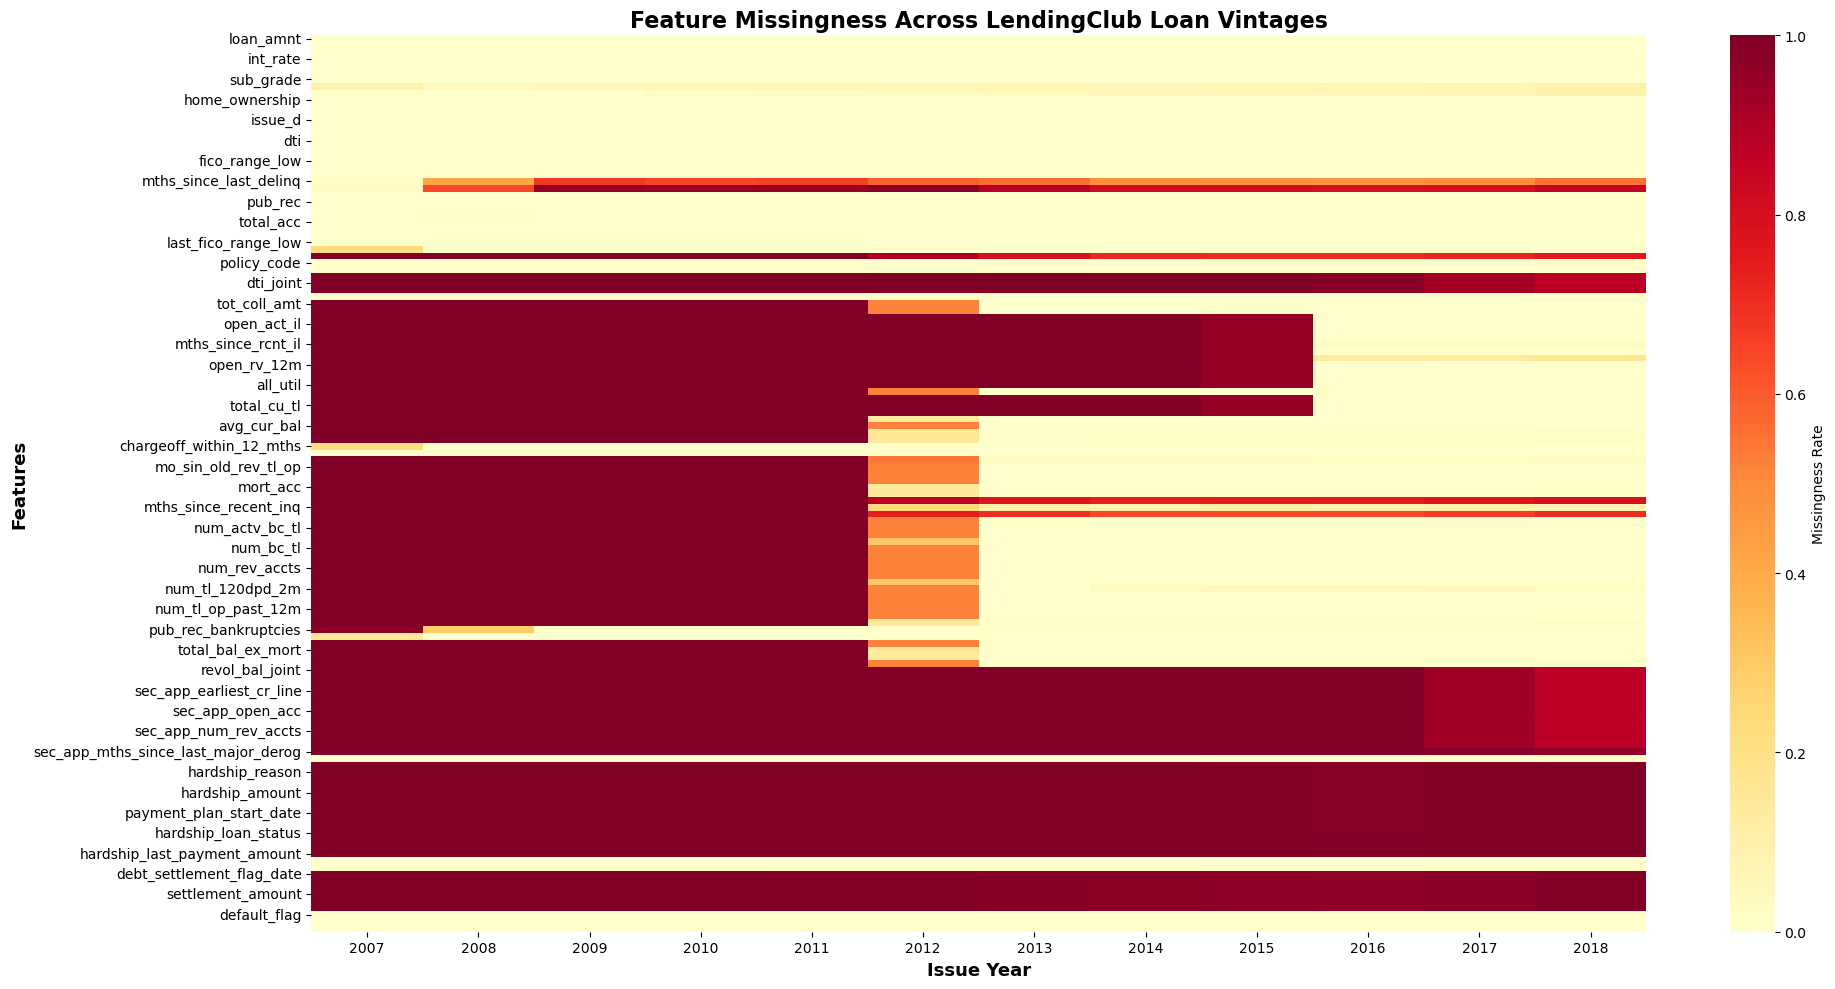

In [18]:
# Visualize feature missingness across loan vintages
plt.figure(figsize=(20, 10))

sns.heatmap(
    missingness_by_year.T,
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    cbar_kws={'label': 'Missingness Rate'}
)

plt.title('Feature Missingness Across LendingClub Loan Vintages', fontsize=16, fontweight='bold')
plt.xlabel('Issue Year', fontsize=13, fontweight='bold')
plt.ylabel('Features', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

A heatmap is used to visualize missingness patterns across LendingClub loan vintages from **2007 to 2018**.

This visualization highlights how feature availability changes over time, making it easier to identify schema drift, late-introduced variables, and persistently sparse features. Variables that appear heavily missing in earlier years but become populated in later vintages are strong indicators of temporal inconsistency and may be unsuitable for robust out-of-time modelling.

It is important to note that certain variables such as `grade`, `sub_grade`, and `int_rate` may appear stable across vintages but remain excluded from the predictive feature set. These variables represent LendingClub’s internal credit risk assessment and pricing decisions, and are therefore retained only for exploratory analysis and benchmarking rather than model training.

This visualization supports the identification of temporally stable, deployment-ready features for the final credit risk modelling pipeline.

### D. Feature Stability Classification

Following the cross-vintage feature availability assessment, each variable is classified according to its missingness behaviour across loan issuance years to determine its suitability for predictive modelling.

The classification framework groups features into four categories:

- **CONSISTENT** — features with less than 10% missing values across all loan vintages, indicating stable availability and suitability for modelling.
- **PARTIAL** — features that are reasonably available in some years but exhibit higher missingness in others, requiring further review before inclusion.
- **LATE_ADDED** — features largely absent in earlier loan vintages (particularly before 2013) but introduced in later years, making them unsuitable for temporally robust modelling.
- **SPARSE** — features with substantial missingness across the overall dataset, limiting their practical predictive value.

This classification provides a structured decision framework for distinguishing deployment-safe features from unstable or low-quality variables, ensuring that the final modelling feature set remains temporally consistent and methodologically reliable.

In [19]:
# Defined function to classify our dataset into 4 categories

def classify_feature(miss_series):
    """
    CONSISTENT  : <10% null in ALL vintage years — safe to use as feature
    PARTIAL      : <10% in some years, >10% in others — review individually
    LATE-ADDED   : >50% null before 2013 — only exists in recent vintages
    SPARSE       : >40% null across ALL years — not useful
    """
    if miss_series.max() < 0.10:
        return 'CONSISTENT'
    
    if miss_series.mean() > 0.40:
        return 'SPARSE'
    
    if miss_series[miss_series.index <= 2013].mean() > 0.50:
        return 'LATE_ADDED'
    
    return 'PARTIAL'


survivability = missingness_by_year.apply(classify_feature)

print("Feature classification summary:")
print(survivability.value_counts())

print()
print("CONSISTENT features (safe for modelling):")
consistent_cols = survivability[survivability == 'CONSISTENT'].index.tolist()
print(consistent_cols)

Feature classification summary:
SPARSE        89
CONSISTENT    39
PARTIAL        4
Name: count, dtype: int64

CONSISTENT features (safe for modelling):
['loan_amnt', 'funded_amnt', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'last_fico_range_high', 'last_fico_range_low', 'policy_code', 'application_type', 'acc_now_delinq', 'delinq_amnt', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag', 'default_flag', 'issue_d_parsed', 'issue_year']


### E. Constructing the Final CONSISTENT_FEATURES List

Following feature stability classification, the next step is to construct the final list of model-eligible features.

Although a feature may be classified as temporally consistent across loan vintages, this alone does not guarantee suitability for predictive modelling. Additional exclusions are required to remove variables associated with target leakage, target construction, temporal tracking, and lender-derived risk assessments that could compromise model validity.

This step applies these exclusion rules to produce a refined pool of candidate features for downstream modelling, while also allowing controlled analyst overrides where domain knowledge supports inclusion.

In [20]:
# Engineer controlled vintage features directly from issue_d — no dependency on
# downstream columns. issue_d is formatted 'Mon-YYYY' (e.g. 'Dec-2014').
# Raw issue_d remains excluded; only these controlled features enter the model.
df['vintage_year']    = pd.to_datetime(df['issue_d'], format='%b-%Y').dt.year
df['vintage_quarter'] = pd.to_datetime(df['issue_d'], format='%b-%Y').dt.quarter

# Columns that must never appear in the feature matrix
POST_ORIGINATION_LEAKAGE = [
    'last_fico_range_low',
    'last_fico_range_high',
    'last_pymnt_amnt',
    'last_pymnt_d'
]
EXCLUDE_FROM_FEATURES = set(
    MODEL_EXCLUDED_COLUMNS +
    LEAKAGE_COLUMNS +
    POST_ORIGINATION_LEAKAGE +
    ['default_flag', 'issue_d', 'issue_d_parsed', 'issue_year']
)
CONSISTENT_FEATURES = [
    c for c in consistent_cols
    if c not in EXCLUDE_FROM_FEATURES
]
# Analyst overrides — add engineered features or columns with 10-20% missingness
# if justified. Format: {'column_name': 'reason for inclusion'}
ANALYST_OVERRIDES = {
    'vintage_year':    ('Cohort year extracted directly from issue_d. Structural '
                        'time dimension for vintage effects, not a macro covariate. '
                        'Raw issue_d excluded — only this controlled feature enters '
                        'the model.'),
    'vintage_quarter': ('Cohort quarter extracted directly from issue_d. '
                        'Same justification as vintage_year.'),
}
CONSISTENT_FEATURES.extend(
    col for col in ANALYST_OVERRIDES
    if col not in CONSISTENT_FEATURES
)
print(f"Approved feature candidates: {len(CONSISTENT_FEATURES)}")
print()
print("Final CONSISTENT_FEATURES list:")
print(CONSISTENT_FEATURES)

Approved feature candidates: 32

Final CONSISTENT_FEATURES list:
['loan_amnt', 'funded_amnt', 'term', 'installment', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'policy_code', 'application_type', 'acc_now_delinq', 'delinq_amnt', 'hardship_flag', 'disbursement_method', 'debt_settlement_flag', 'vintage_year', 'vintage_quarter']


#### Feature Selection Outcome

The filtering process produced the final **CONSISTENT_FEATURES** list, representing variables considered eligible for predictive modelling.

This final feature set excludes leakage-prone variables, target-related fields, temporal identifiers, and LendingClub’s internally generated risk assessment variables, ensuring that the retained predictors reflect information realistically available at the point of loan origination.

The resulting feature pool provides a methodologically sound foundation for subsequent preprocessing, feature engineering, and model development.

#### Feature Governance Configuration Export

A structured feature governance file was exported in JSON format to preserve the finalized modeling feature framework and ensure reproducibility across the project pipeline. The file documents approved consistent features, excluded model variables, identified leakage columns, and analyst-defined overrides used to support transparent and controlled feature selection decisions.

In [21]:
#Save to JSON
output = {
    'consistent_features': CONSISTENT_FEATURES,
    'model_excluded': MODEL_EXCLUDED_COLUMNS,
    'leakage_columns': LEAKAGE_COLUMNS,
    'analyst_overrides': ANALYST_OVERRIDES
}

with open('../data/processed/consistent_features.json', 'w') as f:
    json.dump(output, f, indent=2)

print('Saved: data/processed/consistent_features.json')
print(f'Total approved feature candidates: {len(CONSISTENT_FEATURES)}')

Saved: data/processed/consistent_features.json
Total approved feature candidates: 32


# Two-Stage Stratified Sampling Strategy

To balance computational efficiency with modelling robustness, a two-stage stratified sampling strategy is adopted for this project.

Working with the full LendingClub dataset throughout model development would be computationally expensive and unnecessarily slow for iterative experimentation. To address this, two representative samples are created:

- **Development Sample (100,000 records):** used for exploratory analysis, feature engineering, model experimentation, and early model evaluation.
- **Production Sample (500,000 records):** reserved for final benchmark evaluation and comparative model performance assessment.

Both samples are generated using **stratified sampling based on loan issue year and target class (`default_flag`)** to preserve the temporal structure of the dataset and maintain the original class distribution across sampling stages.

This approach enables efficient model development without compromising the representativeness and reliability of final performance evaluation.

### Stratified Sampling Function

A stratified sampling function is defined to create representative subsets of the dataset while preserving the original distribution of both **loan issuance year (`issue_year`)** and **target class (`default_flag`)**.

This ensures that each sample accurately reflects the temporal structure and default/non-default class balance of the full dataset, supporting reliable model development and evaluation.

In [22]:
def stratified_sample(df, n_target, random_state=42):
    """
    Generate a representative stratified sample of the dataset
    using proportional allocation across issue_year and default_flag strata.

    This sampling approach preserves:
    - The temporal distribution of loan vintages
    - The class distribution of default and non-default loans within each vintage

    This ensures the sampled dataset remains representative of the
    full population for reliable model development and evaluation.
    """
    strata = df.groupby(['issue_year', 'default_flag']).size()
    proportions = strata / len(df)
    counts = (proportions * n_target).apply(np.floor).astype(int)

    remainder = n_target - counts.sum()
    fractions = (proportions * n_target) - counts
    counts[fractions.nlargest(int(remainder)).index] += 1

    assert counts.sum() == n_target, 'Count allocation error'

    samples = []
    for (year, flag), n in counts.items():
        stratum = df[
            (df['issue_year'] == year) &
            (df['default_flag'] == flag)
        ]
        samples.append(stratum.sample(n=min(n, len(stratum)), random_state=random_state))

    return pd.concat(samples, ignore_index=True)

## Creating the Development Sample

To support efficient model development, experimentation, and iterative testing, a representative **100,000-observation development sample** is generated from the full LendingClub dataset using the stratified sampling framework.

The sampling process preserves the original distribution of both **loan issuance year (`issue_year`)** and **default class (`default_flag`)**, ensuring that the reduced dataset remains representative of the full modelling population while significantly improving computational efficiency.

In [23]:
# Extract year from issue_d before stratified sampling
df_resolved['issue_year'] = pd.to_datetime(df_resolved['issue_d'], format='%b-%Y').dt.year

# Create 100k development sample
df_dev = stratified_sample(df_resolved, n_target=100_000)

# Compare default rates
dev_rate = df_dev['default_flag'].mean()
resolved_full_rate = df_resolved['default_flag'].mean()

print(f"Original sample size:{len(df_resolved):,} rows")
print(f"Original default rate: {resolved_full_rate*100:.2f}%")
print()
print(f"Development sample size: {len(df_dev):,} rows")
print(f"Development default rate: {dev_rate*100:.2f}%")
print()
print('Development sample Rows by year:')
print(df_dev['issue_year'].value_counts().sort_index())

Original sample size:1,345,350 rows
Original default rate: 19.96%

Development sample size: 100,000 rows
Development default rate: 19.97%

Development sample Rows by year:
issue_year
2007       18
2008      116
2009      350
2010      858
2011     1614
2012     3967
2013    10020
2014    16584
2015    27915
2016    21786
2017    12585
2018     4187
Name: count, dtype: int64


## Creating the Production Sample

To support robust final model evaluation and benchmarking, a representative **500,000-observation production sample** is generated from the full LendingClub dataset using the same stratified sampling framework.

This larger sample preserves the original distribution of both **loan issuance year (`issue_year`)** and **default class (`default_flag`)**, providing a computationally practical yet highly representative dataset for final comparative model assessment.

In [24]:
# Create 500k production sample
df_prod = stratified_sample(df_resolved, n_target=500_000)

# Compare default rates
prod_rate = df_prod['default_flag'].mean()
resolved_full_rate = df_resolved['default_flag'].mean()

print(f"Original sample size: {len(df_resolved):,} rows")
print(f"Original default rate: {resolved_full_rate*100:.2f}%")
print()
print(f"Production sample size: {len(df_prod):,} rows")
print(f"Production default rate: {prod_rate*100:.2f}%")


print()
print("Loans by issue year:")
print(df_prod['issue_year'].value_counts().sort_index())

Original sample size: 1,345,350 rows
Original default rate: 19.96%

Production sample size: 500,000 rows
Production default rate: 19.97%

Loans by issue year:
issue_year
2007        93
2008       581
2009      1753
2010      4288
2011      8072
2012     19833
2013     50100
2014     82916
2015    139572
2016    108933
2017     62928
2018     20931
Name: count, dtype: int64


#### Dataset Export
The processed Lending Club datasets were exported as optimized Parquet files for efficient storage and faster analytical workflows. Separate development and production datasets were created to support model experimentation, validation, and scalable downstream deployment processes.

In [25]:
df_dev.to_parquet('../data/processed/loans_dev_100k.parquet', index=False)
df_prod.to_parquet('../data/processed/loans_prod_500k.parquet', index=False)

print('Saved: data/processed/loans_dev_100k.parquet')
print('Saved: data/processed/loans_prod_500k.parquet')
print()

Saved: data/processed/loans_dev_100k.parquet
Saved: data/processed/loans_prod_500k.parquet



## Layer 2: Canadian Macroeconomic Data Acquisition

To support the macroeconomic layer of the credit risk modelling framework, relevant Canadian economic indicators are collected from authoritative public data sources and consolidated into a unified monthly macroeconomic panel.

This layer captures broader economic conditions that may influence credit risk behaviour at the portfolio level, including monetary policy, labour market conditions, inflation, household financial stress, and consumer insolvency trends.

The macroeconomic panel includes the following indicators:

- **Bank of Canada overnight policy rate**
- **National unemployment rate**
- **Consumer Price Index (CPI) – all items**
- **Household debt-service ratio**
- **Consumer insolvency filings**

Because these indicators are reported at different frequencies, all series are standardized to a consistent monthly time structure to support downstream temporal analysis and macro-level modelling integration.

To maintain methodological integrity, this macroeconomic dataset remains fully separate from the individual LendingClub borrower-level loan records and is used exclusively for the macroeconomic modelling layer.

### Memory-Efficient StatsCan Data Ingestion

This helper uses incremental parquet writing rather than accumulating multiple DataFrames in memory with `pd.concat()`. This approach reduces memory overhead, improves scalability for large Statistics Canada ZIP datasets, and prevents notebook crashes during ingestion.

In [26]:
def download_statcan(table_id, filter_func, chunk_size=100_000, max_retries=3):
    """
    Download and filter a Statistics Canada table using memory-efficient chunked processing.

    Designed for large datasets to improve scalability, reduce memory pressure,
    and ensure reliable notebook execution.
    """
    api_url = f'https://www150.statcan.gc.ca/t1/wds/rest/getFullTableDownloadCSV/{table_id}/en'

    for attempt in range(max_retries):
        try:
            r = requests.get(api_url, timeout=30)
            r.raise_for_status()
            zip_url = r.json()['object']
            print(f'ZIP URL: {zip_url}')
            break
        except Exception as e:
            if attempt == max_retries - 1:
                raise
            print(f'Retry {attempt + 1}: {e}')

    print('Downloading ZIP...')
    r2 = requests.get(zip_url, timeout=600)
    r2.raise_for_status()
    print(f'Downloaded: {len(r2.content)/1e6:.1f} MB')

    chunk_paths = []
    
    with zipfile.ZipFile(io.BytesIO(r2.content)) as z:
        csv_file = [f for f in z.namelist() if f.endswith('.csv') and 'Meta' not in f][0]

        with z.open(csv_file) as f:
            for i, chunk in enumerate(pd.read_csv(f, chunksize=chunk_size, low_memory=False)):
                filtered = filter_func(chunk)

                if not filtered.empty:
                    path = f'data/raw/macro_chunks/{table_id}_chunk_{i:04d}.parquet'
                    filtered.to_parquet(path, index=False)
                    chunk_paths.append(path)

    if not chunk_paths:
        raise ValueError(f'No rows matched filter for table {table_id}')

    df = pd.concat([pd.read_parquet(p) for p in chunk_paths], ignore_index=True)

    for p in chunk_paths:
        os.remove(p)

    print(f'Filtered rows: {len(df):,}')
    return df

## Series 1: Bank of Canada Overnight Policy Rate

This series captures the **Bank of Canada’s overnight policy rate**, a core indicator of monetary policy and borrowing conditions. Changes in interest rates can influence credit affordability, borrower repayment capacity, and broader economic conditions relevant to credit risk modelling.

Source: https://www.bankofcanada.ca/valet/observations/V39079/json

In [27]:
# ── Series 1: Bank of Canada Overnight Policy Rate (2000 → present) ──────────
# V39079  = current overnight rate series (2009 → present)
# V122530 = legacy overnight rate series (1990 → 2009) — fills the gap
print('=== Bank of Canada Overnight Rate ===')

def fetch_boc_series(series_id):
    url = f'https://www.bankofcanada.ca/valet/observations/{series_id}/json'
    observations = requests.get(url, timeout=30).json()['observations']
    return pd.DataFrame([
        {
            'date': pd.to_datetime(obs['d']),
            'overnight_rate': pd.to_numeric(obs[series_id]['v'], errors='coerce')
        }
        for obs in observations
    ])

# Fetch both series and combine
boc_new    = fetch_boc_series('V39079')   # 2009 → present
boc_legacy = fetch_boc_series('V122530')  # 1990 → 2009

boc_daily = (
    pd.concat([boc_legacy, boc_new])
    .drop_duplicates(subset='date')
    .sort_values('date')
    .reset_index(drop=True)
)

boc_monthly = (
    boc_daily
    .set_index('date')
    .resample('MS')
    .mean()
    .reset_index()
    .query("date >= '2000-01-01'")
    .dropna()
    .reset_index(drop=True)
)

print(f'Observations:  {len(boc_daily):,}')
print(f'Monthly rows:  {len(boc_monthly):,}')
print(f'Date range:    {boc_monthly.date.min().date()} → {boc_monthly.date.max().date()}')
print(f'Latest rate:   {boc_monthly.overnight_rate.iloc[-1]:.2f}%')
print(boc_monthly.tail(3).to_string(index=False))

=== Bank of Canada Overnight Rate ===
Observations:  5,400
Monthly rows:  317
Date range:    2000-01-01 → 2026-05-01
Latest rate:   2.26%
      date  overnight_rate
2026-03-01        2.260870
2026-04-01        2.261905
2026-05-01        2.262500


## Series 2: National Unemployment Rate

This series captures Canada's **national unemployment rate**, a key indicator of labour market conditions and overall economic health. Rising unemployment can weaken household repayment capacity and increase credit default risk, making it an important macroeconomic input for credit risk analysis.

Source: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1410028701

In [28]:
# ── Series 2: Unemployment Rate (Table 14-10-0287-01) ────────────────
print('=== Series 2: Unemployment Rate (Table 14-10-0287-01) ===')

def filter_unemployment(chunk):
    return chunk[
        (chunk['GEO'] == 'Canada') &
        (chunk['Labour force characteristics'] == 'Unemployment rate') &
        (chunk['Gender'] == 'Total - Gender') &
        (chunk['Age group'] == '15 years and over') &
        (chunk['Statistics'] == 'Estimate') &
        (chunk['Data type'] == 'Seasonally adjusted')
    ][['REF_DATE', 'VALUE']].copy()

unemp_raw = download_statcan('14100287', filter_unemployment)
unemp_raw.columns = ['date', 'unemployment_rate']
unemp_raw['date'] = pd.to_datetime(unemp_raw['date'] + '-01')
unemp_raw = unemp_raw.dropna().sort_values('date').reset_index(drop=True)
unemp_monthly = unemp_raw[unemp_raw['date'] >= '2000-01-01'].copy()

print(f'Monthly rows: {len(unemp_monthly)}')
print(f'Latest: {unemp_monthly["unemployment_rate"].iloc[-1]}%')
print(unemp_monthly.tail(3).to_string(index=False))

=== Series 2: Unemployment Rate (Table 14-10-0287-01) ===
ZIP URL: https://www150.statcan.gc.ca/n1/tbl/csv/14100287-eng.zip
Downloaded: 60.0 MB
Filtered rows: 604
Monthly rows: 316
Latest: 6.9%
      date  unemployment_rate
2026-02-01                6.7
2026-03-01                6.7
2026-04-01                6.9


## Series 3: Consumer Price Index (CPI) – All Items

This series captures Canada's **Consumer Price Index (CPI) for all items**, a key measure of inflation and changes in the general price level. Rising inflation can reduce household purchasing power, increase financial stress, and indirectly influence borrower repayment behaviour, making it a relevant macroeconomic variable for credit risk analysis.

Source: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1810000401

*Note: This data extraction may take a few minutes due to the size of the Statistics Canada source dataset.*

In [29]:
# ── Series 3: Consumer Price Index (CPI) (Table 1810000401) ───────────────────────
print('=== Series 3: CPI All Items ===')

cpi_raw = download_statcan('18100004', lambda chunk: chunk)

product_col = next(
    (col for col in cpi_raw.columns if 'product' in col.lower() or 'item' in col.lower()),
    'Products and product groups'
)

cpi_monthly = (
    cpi_raw[
        (cpi_raw['GEO'] == 'Canada') &
        (cpi_raw[product_col].str.strip() == 'All-items')
    ][['REF_DATE', 'VALUE']]
    .rename(columns={'REF_DATE': 'date', 'VALUE': 'cpi'})
)

cpi_monthly['date'] = pd.to_datetime(cpi_monthly['date'] + '-01')
cpi_monthly = (
    cpi_monthly
    .dropna()
    .sort_values('date')
    .query("date >= '2000-01-01'")
    .reset_index(drop=True)
)

print(f'Monthly rows: {len(cpi_monthly):,}')
print(f'Latest CPI: {cpi_monthly.cpi.iloc[-1]}')
print(cpi_monthly.tail(3).to_string(index=False))

=== Series 3: CPI All Items ===
ZIP URL: https://www150.statcan.gc.ca/n1/tbl/csv/18100004-eng.zip
Downloaded: 15.2 MB
Filtered rows: 1,144,893
Monthly rows: 316
Latest CPI: 168.0
      date   cpi
2026-02-01 165.9
2026-03-01 167.4
2026-04-01 168.0


## Series 4: Household Debt-Service Ratio

This series captures Canada's **household debt-service ratio**, which measures the proportion of household disposable income used to service debt obligations. Higher debt-service burdens may indicate increased household financial stress and reduced repayment capacity, making this an important macroeconomic indicator for credit risk analysis.

Source: https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1110006501

*Note: This series is reported quarterly and will be converted to a monthly frequency for consistency with the macroeconomic panel.*

In [30]:
# ── Series 4: Debt-Service Ratio (Table 11-10-0065-01) ───────────────────────
print('Series 4: Debt-Service Ratio (Table 11-10-0065-01)')
# Quarterly series — forward-filled to monthly to match other macro series.
dsr_raw = download_statcan('11100065', lambda chunk: chunk)

# Filter: debt-service ratio rows only (UOM = Ratio, seasonally adjusted)
dsr_filtered = dsr_raw[
    (dsr_raw['Estimates'] == 'Debt service ratio') &
    (dsr_raw['UOM'] == 'Ratio') &
    (dsr_raw['Seasonal adjustment'] == 'Seasonally adjusted at annual rates')
][['REF_DATE', 'VALUE']].copy()
dsr_filtered.columns = ['date', 'debt_service_ratio']

# Parse quarterly dates (format: 1990-01 → 1990-01-01)
dsr_filtered['date'] = pd.to_datetime(dsr_filtered['date'] + '-01')
dsr_filtered = dsr_filtered.dropna().sort_values('date').reset_index(drop=True)
dsr_quarterly = dsr_filtered[dsr_filtered['date'] >= '2000-01-01'].copy()

# Forward-fill quarterly values to monthly frequency
monthly_index = pd.date_range(start=dsr_quarterly['date'].min(),
                               end=dsr_quarterly['date'].max(), freq='MS')
dsr_monthly = (dsr_quarterly.set_index('date')
                             .reindex(monthly_index)
                             .ffill()
                             .reset_index())
dsr_monthly.columns = ['date', 'debt_service_ratio']

print(f'Date range:          {dsr_monthly["date"].min().date()} → {dsr_monthly["date"].max().date()}')
print(f'Quarterly rows:      {len(dsr_quarterly)}')
print(f'Monthly after ffill: {len(dsr_monthly)}')
print(dsr_monthly.tail(3).to_string(index=False))

Series 4: Debt-Service Ratio (Table 11-10-0065-01)
ZIP URL: https://www150.statcan.gc.ca/n1/tbl/csv/11100065-eng.zip
Downloaded: 0.1 MB
Filtered rows: 8,352
Date range:          2000-01-01 → 2025-10-01
Quarterly rows:      104
Monthly after ffill: 310
      date  debt_service_ratio
2025-08-01               14.61
2025-09-01               14.61
2025-10-01               14.57


## Series 5: Consumer Insolvencies

This series captures **Canadian consumer insolvency filings**, an indicator of household financial distress and worsening credit conditions. Rising insolvency levels may signal increased repayment stress among consumers, making this a relevant macroeconomic variable for credit risk analysis.

Source: Statistics Canada WDS Vector API (`v41690973`)

In [31]:
# ── Series 5: Consumer Insolvencies ───────────────────
print('=== Series 5: Consumer Insolvencies (vector v41690973) ===')

url = 'https://www150.statcan.gc.ca/t1/wds/rest/getDataFromVectorsAndLatestNPeriods'
payload = [{'vectorId': 41690973, 'latestN': 300}]
r = requests.post(url, json=payload,
                  headers={'Content-Type': 'application/json'}, timeout=30)
print(f'HTTP status: {r.status_code}')

if r.status_code == 200:
    data_points = r.json()[0]['object']['vectorDataPoint']
    insolvency_monthly = pd.DataFrame([
        {'date': pd.to_datetime(obs['refPer'] + '-01'),
         'consumer_insolvencies': float(obs['value'])}
        for obs in data_points
    ]).sort_values('date').reset_index(drop=True)
    insolvency_monthly = insolvency_monthly[
        insolvency_monthly['date'] >= '2000-01-01'
    ].copy()
    print(f'Monthly rows: {len(insolvency_monthly)}')
    print(f'Latest: {insolvency_monthly["consumer_insolvencies"].iloc[-1]:,.0f} insolvencies')
    print(insolvency_monthly.tail(3).to_string(index=False))
else:
    print(f'Failed ({r.status_code}). Creating placeholder.')
    insolvency_monthly = pd.DataFrame({
        'date': pd.date_range('2000-01-01', periods=300, freq='MS'),
        'consumer_insolvencies': np.nan
    })

# Strip timezone/time component so dates align with other series
insolvency_monthly['date'] = pd.to_datetime(insolvency_monthly['date']).dt.normalize()

# Verify fix
print(insolvency_monthly.head(3).to_string(index=False))

=== Series 5: Consumer Insolvencies (vector v41690973) ===
HTTP status: 200
Monthly rows: 300
Latest: 168 insolvencies
               date  consumer_insolvencies
2026-02-01 01:00:00                  165.9
2026-03-01 01:00:00                  167.4
2026-04-01 01:00:00                  168.0
      date  consumer_insolvencies
2001-05-01                   98.6
2001-06-01                   98.7
2001-07-01                   98.4


## Constructing the Unified Macroeconomic Panel

The five macroeconomic series collected in the previous steps are now integrated into a single unified monthly macroeconomic panel. These include:

- **Bank of Canada overnight policy rate**
- **National unemployment rate**
- **Consumer Price Index (CPI) – all items**
- **Household debt-service ratio**
- **Consumer insolvency filings**

Combining these indicators into a common monthly time series creates the consolidated macroeconomic dataset required for the downstream macro-level credit risk modelling layer.

In [32]:
print('=== Merging all 5 series ===')

macro_panel = boc_monthly.copy()
macro_panel = macro_panel.merge(unemp_monthly,     on='date', how='left')
macro_panel = macro_panel.merge(cpi_monthly,        on='date', how='left')
macro_panel = macro_panel.merge(dsr_monthly,        on='date', how='left')
macro_panel = macro_panel.merge(insolvency_monthly, on='date', how='left')
macro_panel = macro_panel.sort_values('date').reset_index(drop=True)

print(f'Panel shape: {macro_panel.shape}')
print(f'Date range: {macro_panel["date"].min().date()} to {macro_panel["date"].max().date()}')
print()
print('Null counts:')
print(macro_panel.isnull().sum())

=== Merging all 5 series ===
Panel shape: (317, 6)
Date range: 2000-01-01 to 2026-05-01

Null counts:
date                      0
overnight_rate            0
unemployment_rate         1
cpi                       1
debt_service_ratio        7
consumer_insolvencies    17
dtype: int64


## Handling Missing Values in the Macroeconomic Panel

Because the macroeconomic series originate from different sources and publication schedules, some missing values are expected at the beginning or end of certain time series.

Where appropriate, missing values are handled using **backward-fill** or **forward-fill** imputation to maintain a complete and aligned monthly macroeconomic panel:

- **Consumer insolvencies:** early missing months before the series begins are back-filled, while the most recent unpublished observation is forward-filled.
- **Household debt-service ratio:** recent unpublished quarters are forward-filled.
- **Unemployment rate and CPI:** latest unpublished monthly observations are forward-filled.

This ensures a complete macroeconomic panel with no remaining null values, ready for downstream modelling and temporal analysis.


In [33]:
# Handle nulls/missing values in macro panel
# consumer_insolvencies: early months before series starts — back-fill from first known value
macro_panel['consumer_insolvencies'] = macro_panel['consumer_insolvencies'].bfill()

# Forward-fill the single trailing null in consumer_insolvencies (May 2026 not yet published)
macro_panel['consumer_insolvencies'] = macro_panel['consumer_insolvencies'].ffill()

# debt_service_ratio: recent quarters not yet published — forward-fill from last known value
macro_panel['debt_service_ratio'] = macro_panel['debt_service_ratio'].ffill()

# unemployment_rate + cpi: most recent month not yet published — forward-fill
macro_panel['unemployment_rate'] = macro_panel['unemployment_rate'].ffill()
macro_panel['cpi'] = macro_panel['cpi'].ffill()

# Verify no nulls remain 
print(f"Panel shape: {macro_panel.shape}")
print(f"Date range:  {macro_panel['date'].min().date()} → {macro_panel['date'].max().date()}")
print()
print("Null counts after fix:")
print(macro_panel.isna().sum())
print()
print(macro_panel.tail(3).to_string(index=False))

Panel shape: (317, 6)
Date range:  2000-01-01 → 2026-05-01

Null counts after fix:
date                     0
overnight_rate           0
unemployment_rate        0
cpi                      0
debt_service_ratio       0
consumer_insolvencies    0
dtype: int64

      date  overnight_rate  unemployment_rate   cpi  debt_service_ratio  consumer_insolvencies
2026-03-01        2.260870                6.7 167.4               14.57                  167.4
2026-04-01        2.261905                6.9 168.0               14.57                  168.0
2026-05-01        2.262500                6.9 168.0               14.57                  168.0


## Final Macro Panel Dataset Export

The fully cleaned and consolidated macroeconomic panel dataset was exported and saved as a Parquet file for efficient storage, faster loading, and downstream modeling integration. 

A verification step was performed immediately after saving to confirm successful export, validate the dataset structure, and inspect the final records.

The exported dataset includes all processed macroeconomic indicators merged into a unified time-series panel, ready for feature engineering, exploratory analysis, and machine learning modeling.

**Export Path:**  
`data/processed/macro_panel.parquet`

In [34]:
macro_panel.to_parquet('../data/processed/macro_panel.parquet', index=False)
verify = pd.read_parquet('../data/processed/macro_panel.parquet')
print(f'Saved: data/processed/macro_panel.parquet')
print(f'Shape: {verify.shape}')
print()
print('Last 5 rows:')
print(verify.tail(5).to_string(index=False))

Saved: data/processed/macro_panel.parquet
Shape: (317, 6)

Last 5 rows:
      date  overnight_rate  unemployment_rate   cpi  debt_service_ratio  consumer_insolvencies
2026-01-01        2.261364                6.5 165.0               14.57                  165.0
2026-02-01        2.261905                6.7 165.9               14.57                  165.9
2026-03-01        2.260870                6.7 167.4               14.57                  167.4
2026-04-01        2.261905                6.9 168.0               14.57                  168.0
2026-05-01        2.262500                6.9 168.0               14.57                  168.0
